# MTRN3100 Week 12 Part 2 - Route Planning Output

This notebook presents the two required Part 2 outputs:

1. the complete planned route over the maze image;
2. the robot action route as an `l`, `r`, `f` command string.

It reads the latest files generated by `plan_full_route.py`. It does not run the planner or modify any project output.

In [23]:
import json
from pathlib import Path

from IPython.display import HTML, Image, Markdown, display


def find_project_dir() -> Path:
    candidates = [Path.cwd(), Path.cwd() / "week12_part2"]
    for candidate in candidates:
        if (candidate / "plan_full_route.py").is_file():
            return candidate.resolve()
    raise FileNotFoundError(
        "Could not locate week12_part2. Open this notebook from the project workspace."
    )


PROJECT_DIR = find_project_dir()
OUTPUT_DIR = PROJECT_DIR / "output"
ROUTE_FILE = OUTPUT_DIR / "route.json"
PLANNING_IMAGE = OUTPUT_DIR / "planning_result.png"

for required_file in (ROUTE_FILE, PLANNING_IMAGE):
    if not required_file.is_file():
        raise FileNotFoundError(
            f"Missing {required_file}. Run plan_full_route.py first to generate "
            "the latest Part 2 result."
        )

with ROUTE_FILE.open("r", encoding="utf-8") as stream:
    route = json.load(stream)

print(f"Loaded Part 2 output from: {OUTPUT_DIR}")

Loaded Part 2 output from: D:\3100\MTRN3100-T05\week12_part2\output


## 1. Part 2 Planned Route

The image below is the complete route produced by the existing Part 2 planner. The coloured route sections show travel before, through and after the obstacle course.

**Start:** `[0, 3, 'N']` &nbsp;&nbsp; **Goal:** `[6, 3]` &nbsp;&nbsp; **Detected obstacles:** `2`

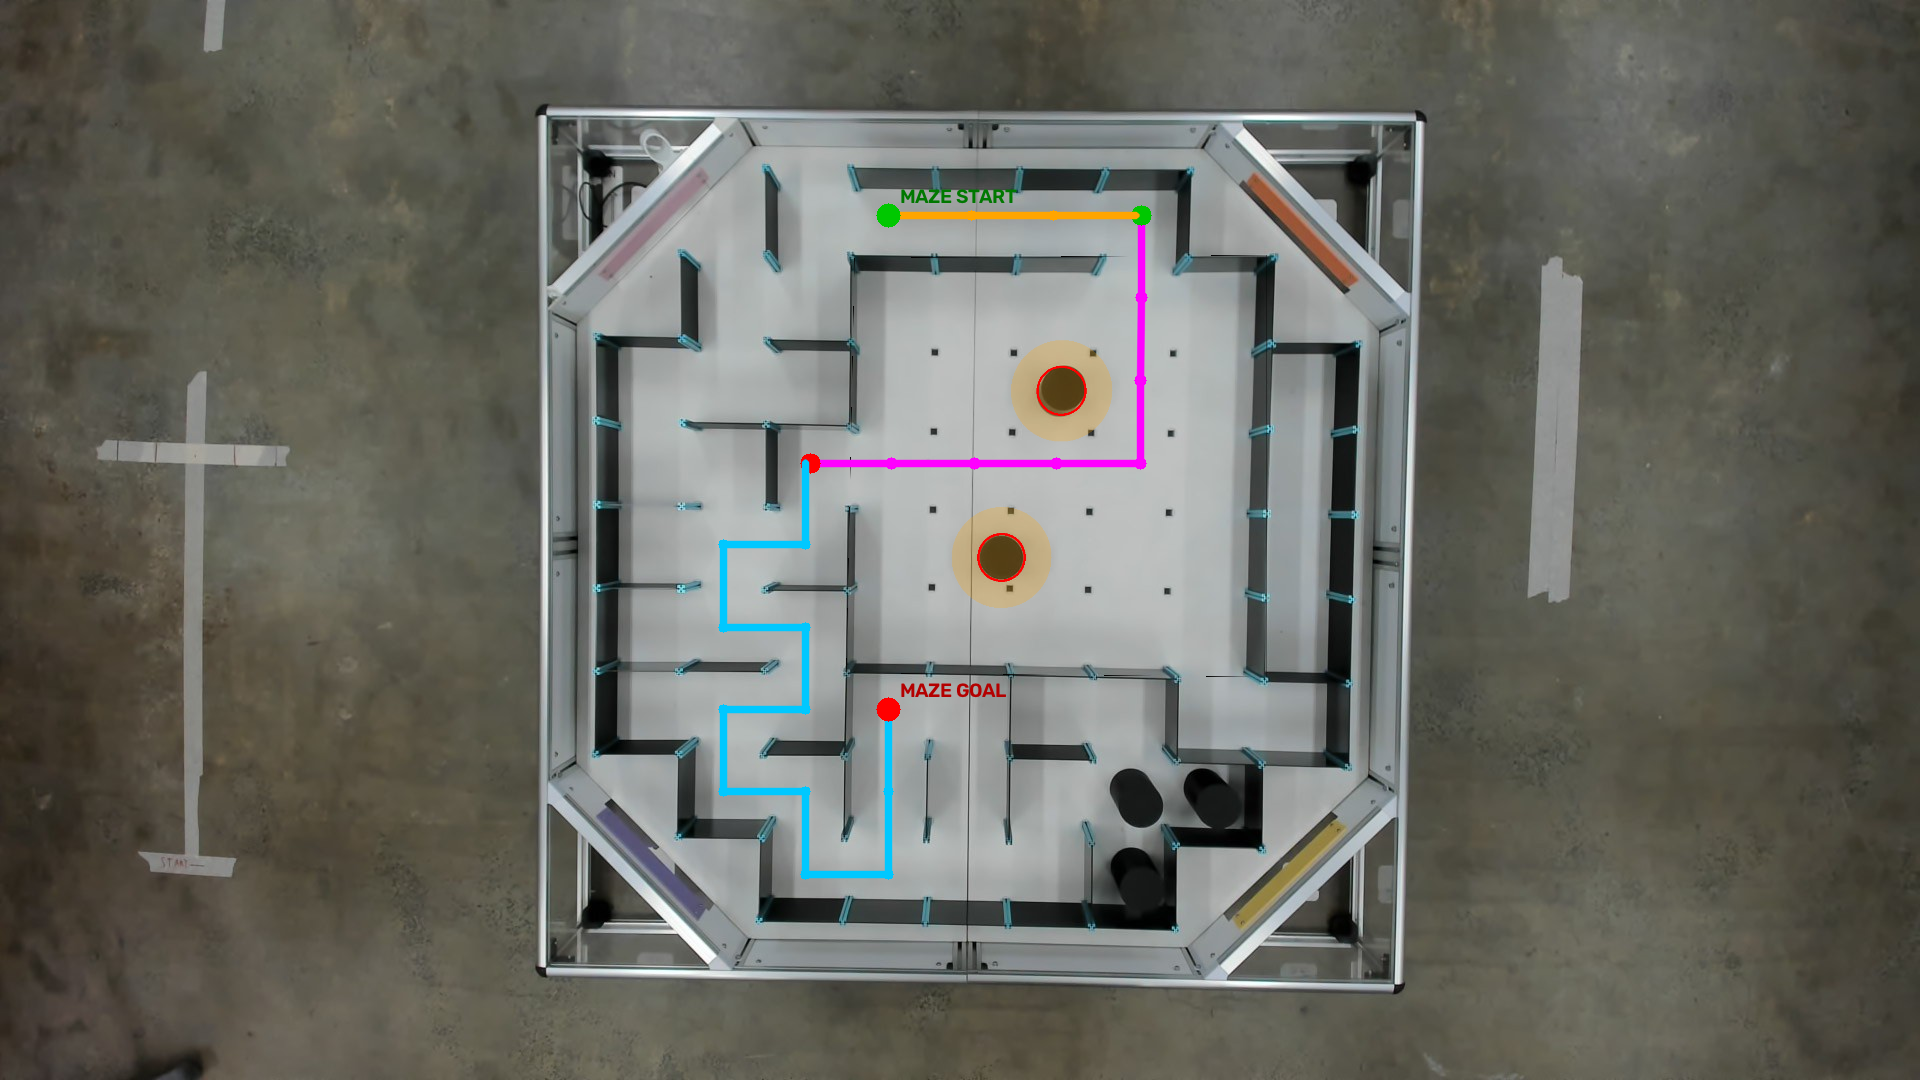

In [24]:
maze_start = route.get("maze_start", "Not recorded")
maze_goal = route.get("maze_goal", "Not recorded")
obstacle_count = len(route.get("obstacles", []))

display(
    Markdown(
        f"**Start:** `{maze_start}` &nbsp;&nbsp; "
        f"**Goal:** `{maze_goal}` &nbsp;&nbsp; "
        f"**Detected obstacles:** `{obstacle_count}`"
    )
)
display(Image(filename=str(PLANNING_IMAGE), width=1000))

## 2. Robot Action Route

Each character is one robot action:

- `f`: move forward;
- `l`: turn left;
- `r`: turn right.

The route is split into travel before the obstacle course, travel through the obstacle course, and travel from the course exit to the final goal.

In [25]:
pre_commands = str(route.get("pre_commands", ""))
course_commands = str(route.get("grid_commands", ""))
post_commands = str(route.get("post_commands", ""))
generated_complete = pre_commands + course_commands + post_commands
complete_commands = str(route.get("complete_commands") or generated_complete)

stages = {
    "Before obstacle course": pre_commands,
    "Through obstacle course": course_commands,
    "After obstacle course": post_commands,
}
for stage_name, commands in {**stages, "Complete route": complete_commands}.items():
    invalid_commands = set(commands) - set("lrf")
    if invalid_commands:
        raise ValueError(f"{stage_name} contains invalid commands: {sorted(invalid_commands)}")

if complete_commands != generated_complete:
    raise ValueError(
        "complete_commands does not match pre_commands + grid_commands + post_commands"
    )

print(f"Before obstacle course: {pre_commands}")
print(f"Through obstacle course: {course_commands}")
print(f"After obstacle course: {post_commands}")
print(f"Complete command string: {complete_commands}")

Before obstacle course: rfffr
Through obstacle course: fffrffff
After obstacle course: lfrflflfrfrflflfrflflff
Complete command string: rfffrfffrfffflfrflflfrfrflflfrflflff
